# Full Bayesian Operator Inference: Compressible Euler

**Workflow:**
1. Generate training data and fit POD basis
2. Grid search for prior operator
3. Fit GP hyperparameters
4. Run Bayesian inference (SVI/MCMC)
5. Evaluate and visualize results

## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    grid_search_prior_operator,
    fit_gp_hyperparameters_mle,
    compute_gp_derivatives,
    run_svi,
    run_mcmc,
    generate_rom_predictions,
)
import config
from config import Basis
from euler_plotter import EulerPlotter

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"         # OpInf operator structure (no inputs)
NUM_MODES = 5             # POD modes to retain

# Data generation settings
TRAINING_SPAN = (0, 0.08)  # Subset of time domain for training
NUM_SAMPLES = 55           # Number of training samples
NOISE_LEVEL = 0.05        # Noise level for training data

# Inference settings
RUN_SVI = True
RUN_MCMC = True           # More expensive, optional
USE_SVI_FOR_MCMC_INIT = True  # Initialize MCMC from SVI result (requires RUN_SVI=True)

# Hyperparameters
GAMMA = 0.1      # Operator prior variance
GAMMA2 = 0.1     # ODE constraint stiffness

## 2. Generate Training Data

In [3]:
# Generate training data using the standard pipeline
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Sampled snapshots: {snapshots_sampled.shape}")

generating training data...done in 0.75 s.
Full time domain: (401,)
True states: (600, 401)
Sampled times: (55,)
Sampled snapshots: (600, 55)


In [4]:
# Fit POD basis
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

Compressed shape: (5, 55)
Cumulative energy: 70.7107%


In [5]:
# Data is already sampled via generate_trajectory
print(f"Training samples: {time_sampled.shape[0]}")
print(f"Training time span: [{time_sampled[0]:.4f}, {time_sampled[-1]:.4f}]")

Training samples: 55
Training time span: [0.0000, 0.0800]


## 3. Grid Search for Prior Operator

In [6]:
# Find best deterministic operator via regularization grid search
result = grid_search_prior_operator(
    basis=basis,
    time_domain_sampled=time_sampled,
    snapshots_sampled=snapshots_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=None,
    input_func=None,
    verbose=True
)

prior_operator = result.operator
rom = result.rom
print(f"\nPrior operator shape: {prior_operator.shape}")

Testing 12 regularization values...
  reg=1.0e-08: UNSTABLE
  reg=1.0e-06: UNSTABLE
  reg=1.0e-04: UNSTABLE
  reg=1.0e-02: UNSTABLE
  reg=1.0e-01: UNSTABLE
  reg=5.0e-01: UNSTABLE
  reg=1.0e+00: UNSTABLE
  reg=5.0e+00: UNSTABLE
  reg=1.0e+01: UNSTABLE
  reg=1.0e+02: STABLE, error=1.216354
  reg=1.0e+03: STABLE, error=1.309210
  reg=1.0e+04: STABLE, error=1.311054

✅ Best reg: 1.0e+02, error: 1.216354

Prior operator shape: (5, 21)


## 4. Fit GP Hyperparameters

In [7]:
# Fit GP for each mode via MLE
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=snapshots_comp_sampled,
    verbose=True
)

Fitting GP hyperparameters via MLE...
  L=0.0039, V=0.2622, N=0.000532
  Mode 0: L=0.0039, V=0.2622, N=0.000532
  L=0.0041, V=0.3268, N=0.000424
  Mode 1: L=0.0041, V=0.3268, N=0.000424
  L=0.0042, V=0.0725, N=0.000257
  Mode 2: L=0.0042, V=0.0725, N=0.000257
  L=0.0033, V=0.1001, N=0.000308
  Mode 3: L=0.0033, V=0.1001, N=0.000308
  L=0.0042, V=0.0990, N=0.000145
  Mode 4: L=0.0042, V=0.0990, N=0.000145


## 5. Bayesian Inference

In [8]:
# Define Bayesian model (no inputs for Euler)
def bayesian_opinf_model(time, gamma=1e-1, gamma2=1e2, normalization=1e-6):
    """Bayesian operator inference model with GP-derived ODE constraints."""
    num_time_steps = time.shape[0]
    
    # Sample operator from prior
    O = numpyro.sample(
        "O",
        dist.Normal(loc=prior_operator, scale=gamma * jnp.ones_like(prior_operator))
    )
    
    # Latent states (GP means)
    Xs = []
    for i in range(NUM_MODES):
        mean_pred, _ = gp_models[i].predict(time[:, None], return_std=True)
        X = numpyro.deterministic(f"X{i}", jnp.array(mean_pred))
        Xs.append(X)
    Xs = jnp.array(Xs)
    
    # Compute operator dynamics (no inputs)
    f_Xi = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T
    
    # GP derivatives
    mu_z, cov_z = compute_gp_derivatives(
        Ls, Vs, time_sampled, time, snapshots_comp_sampled
    )
    
    # ODE constraints
    for i in range(NUM_MODES):
        constraint_cov = cov_z[i] + gamma2 * jnp.eye(num_time_steps)
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(f_Xi.T[i], constraint_cov),
            obs=mu_z[i]
        )

Running SVI (gamma=0.1, gamma2=0.1)...


100%|██████████| 30000/30000 [01:01<00:00, 490.64it/s, init loss: 647078.6875, avg. loss [28501-30000]: 627636.0625] 


✅ SVI complete! Final loss: 627402.7500


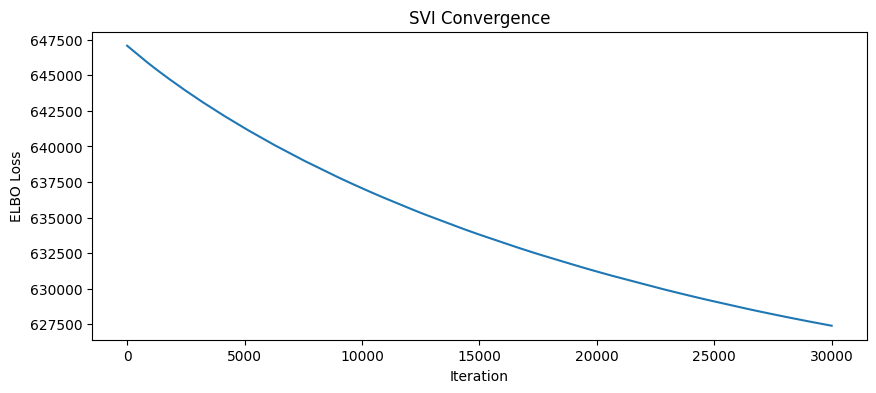

In [9]:
# Run SVI
if RUN_SVI:
    time_eval = time_sampled  # Evaluate at training times
    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=30000,
        learning_rate=1e-4,
        verbose=True
    )
    samples = svi_result.samples
    
    # Extract operator for potential MCMC initialization
    # AutoDelta stores as 'O_auto_loc', MCMC stores as 'O'
    O_key = next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        # Get point estimate (mean over samples or first sample)
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")
    
    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

In [10]:
# Run MCMC (optional, more expensive)
if RUN_MCMC:
    # Initialize from SVI if requested and available
    init_values = None
    if USE_SVI_FOR_MCMC_INIT and RUN_SVI and 'svi_O_init' in dir() and svi_O_init is not None:
        init_values = {"O": svi_O_init}
        print(f"Initializing MCMC from SVI result (shape: {svi_O_init.shape})")
    else:
        print("MCMC will find its own starting point via NUTS adaptation")
    
    mcmc_result = run_mcmc(
        model=bayesian_opinf_model,
        rng_key=jax.random.PRNGKey(1),
        time_eval=time_eval,
        init_values=init_values,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_warmup=500,
        num_samples=500,
        num_chains=2,
        verbose=True
    )
    samples = mcmc_result.samples

MCMC will find its own starting point via NUTS adaptation
Running MCMC (2 chains, 500 warmup, 500 samples)...


sample: 100%|██████████| 1000/1000 [00:02<00:00, 349.85it/s, 15 steps of size 3.21e-01. acc. prob=0.93]


✅ MCMC complete! 1000 samples collected.


## 6. Results and Visualization

In [11]:
# Check sample keys (debug)
print("Sample keys:", list(samples.keys())[:5], "...")
print()

# Generate ROM predictions from posterior (no input_func for Euler)
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples,
    rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_eval,
    num_modes=NUM_MODES,
    num_pulls=200,
    input_func=None,
    data_scaler=None
)

print(f"Collected {len(Os)} operator samples")
print(f"Stable ROM solves: {len(rom_solves)}")

Sample keys: ['O', 'X0', 'X1', 'X2', 'X3'] ...

Collected 200 operator samples
Stable ROM solves: 200


In [12]:
# Operator posterior summary
O_mean = Os.mean(axis=0)
O_std = Os.std(axis=0)

print("Prior operator (first row):")
print(prior_operator[0, :5])
print("\nPosterior mean (first row):")
print(O_mean[0, :5])
print("\nPosterior std (first row):")
print(O_std[0, :5])

Prior operator (first row):
[-6.37156001 -0.31225686  0.54196843  3.7005487   0.98695894]

Posterior mean (first row):
[-4.943062   -4.926971    6.574245    5.534831   -0.93057543]

Posterior std (first row):
[0.07923623 0.07979787 0.0851951  0.08964247 0.08625522]


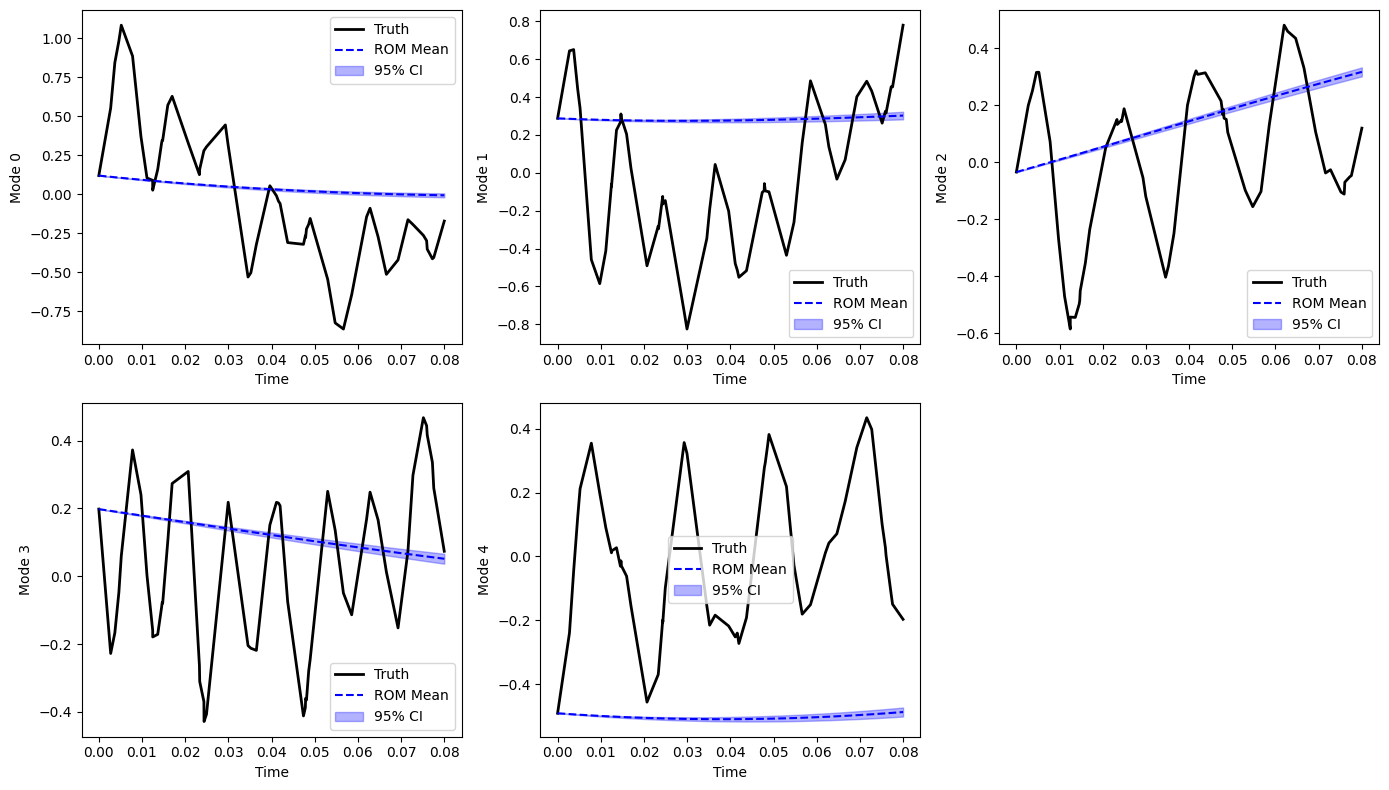

In [13]:
# State reconstruction
if len(rom_solves) > 0:
    rom_mean = rom_solves.mean(axis=0)
    rom_std = rom_solves.std(axis=0)
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for i, ax in enumerate(axes.flat):
        if i >= NUM_MODES:
            ax.axis('off')
            continue
        ax.plot(time_eval, snapshots_comp_sampled[i], 'k-', label='Truth', lw=2)
        ax.plot(time_eval, rom_mean[i], 'b--', label='ROM Mean', lw=1.5)
        ax.fill_between(
            time_eval,
            rom_mean[i] - 2*rom_std[i],
            rom_mean[i] + 2*rom_std[i],
            alpha=0.3, color='blue', label='95% CI'
        )
        ax.set_xlabel('Time')
        ax.set_ylabel(f'Mode {i}')
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No stable ROM solutions found")

In [14]:
# Compute prediction errors
if len(rom_solves) > 0:
    errors = []
    for sol in rom_solves:
        err = np.linalg.norm(sol - snapshots_comp_sampled) / np.linalg.norm(snapshots_comp_sampled)
        errors.append(err)
    
    print(f"Mean relative error: {np.mean(errors):.4%}")
    print(f"Std relative error: {np.std(errors):.4%}")
    print(f"Min relative error: {np.min(errors):.4%}")
    print(f"Max relative error: {np.max(errors):.4%}")

Mean relative error: 128.3368%
Std relative error: 0.3215%
Min relative error: 127.4936%
Max relative error: 129.2217%


## 7. Full-Order Reconstruction

Full-order relative error: 4.0436%


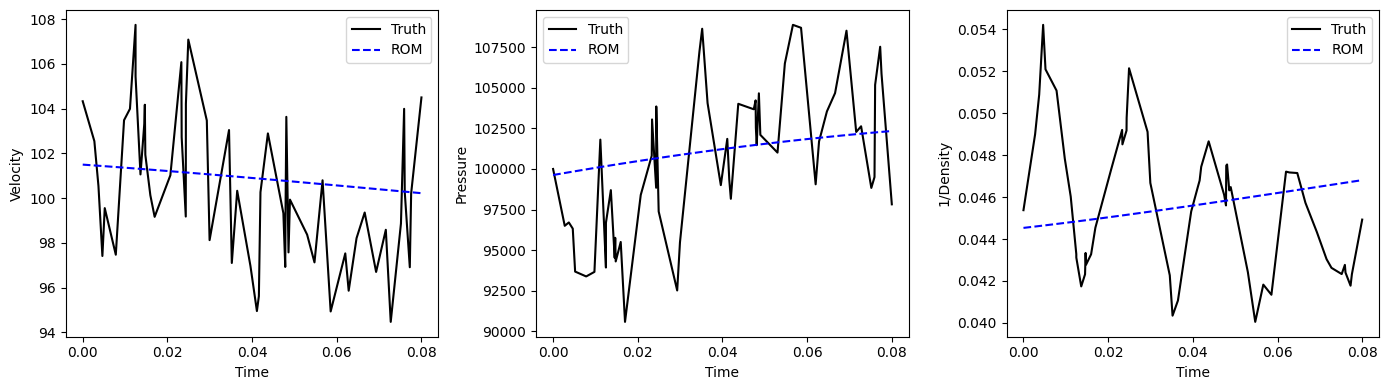

In [15]:
# Reconstruct full-order states
if len(rom_solves) > 0:
    # Decode reduced states to full order
    full_order_mean = basis.decompress(rom_mean)
    full_order_truth = snapshots_sampled
    
    # Full-order error
    full_error = np.linalg.norm(full_order_mean - full_order_truth) / np.linalg.norm(full_order_truth)
    print(f"Full-order relative error: {full_error:.4%}")
    
    # Plot conserved variables at midpoint
    mid_idx = snapshots_sampled.shape[0] // 6  # Approx middle spatial point
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    labels = ['Velocity', 'Pressure', '1/Density']
    for i, (ax, label) in enumerate(zip(axes, labels)):
        idx = i * (snapshots_sampled.shape[0] // 3) + mid_idx
        ax.plot(time_eval, full_order_truth[idx], 'k-', label='Truth')
        ax.plot(time_eval, full_order_mean[idx], 'b--', label='ROM')
        ax.set_xlabel('Time')
        ax.set_ylabel(label)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [16]:
# Summary
print("=" * 50)
print("EXPERIMENT SUMMARY: Compressible Euler")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: {TRAINING_SPAN}")
print(f"Samples: {NUM_SAMPLES}, Noise: {NOISE_LEVEL:.0%}")
print(f"Prior regularization: {result.best_reg:.1e}")
print(f"Prior error: {result.best_error:.4%}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
if len(rom_solves) > 0:
    print(f"Posterior mean error: {np.mean(errors):.4%}")
    print(f"Stable solutions: {len(rom_solves)}/{len(Os)}")

EXPERIMENT SUMMARY: Compressible Euler
Operators: cAH
Modes: 5
Training span: (0, 0.08)
Samples: 55, Noise: 5%
Prior regularization: 1.0e+02
Prior error: 121.6354%
Gamma (operator): 0.1
Gamma2 (ODE): 0.1
Posterior mean error: 128.3368%
Stable solutions: 200/200
